In [2]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [4]:
!pip -q install timm kagglehub

import kagglehub

DATASET_PATH = kagglehub.dataset_download(
    "quandang/vietnamese-foods",
    output_dir="/content/30vnfoods"
)

print("Dataset downloaded to:", DATASET_PATH)

Dataset downloaded to: /content/30vnfoods


In [6]:
from pathlib import Path
from collections import Counter

DATASET_DIR = Path("/content/30vnfoods")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = [
    path for path in DATASET_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

folder_counts = Counter(path.parent for path in image_files)

print("Total images:", len(image_files))
print("Folders containing images:", len(folder_counts))
print("\nLargest image folders:\n")

for folder, count in folder_counts.most_common(40):
    print(f"{count:6d}  {folder}")

Total images: 25136
Folders containing images: 90

Largest image folders:

  1071  /content/30vnfoods/Images/Train/Bun bo Hue
   935  /content/30vnfoods/Images/Train/Banh mi
   821  /content/30vnfoods/Images/Train/Banh xeo
   805  /content/30vnfoods/Images/Train/Bun rieu
   798  /content/30vnfoods/Images/Train/Banh cuon
   751  /content/30vnfoods/Images/Train/Chao long
   688  /content/30vnfoods/Images/Train/Hu tieu
   674  /content/30vnfoods/Images/Train/Banh canh
   659  /content/30vnfoods/Images/Train/Com tam
   640  /content/30vnfoods/Images/Train/Bun dau mam tom
   618  /content/30vnfoods/Images/Train/Mi quang
   598  /content/30vnfoods/Images/Train/Goi cuon
   584  /content/30vnfoods/Images/Train/Banh khot
   577  /content/30vnfoods/Images/Train/Canh chua
   564  /content/30vnfoods/Images/Train/Pho
   556  /content/30vnfoods/Images/Train/Banh trang nuong
   541  /content/30vnfoods/Images/Train/Bun mam
   522  /content/30vnfoods/Images/Train/Bun thit nuong
   520  /content/30vnfoo

In [8]:
from pathlib import Path
from torchvision.datasets import ImageFolder

IMAGES_DIR = Path("/content/30vnfoods/Images")

print("Directories:", [p.name for p in IMAGES_DIR.iterdir() if p.is_dir()])

split_datasets = {}

for split_dir in sorted(p for p in IMAGES_DIR.iterdir() if p.is_dir()):
    dataset = ImageFolder(split_dir)
    split_datasets[split_dir.name] = dataset

    print(f"\n{split_dir.name}")
    print("Images:", len(dataset))
    print("Classes:", len(dataset.classes))
    print("First five classes:", dataset.classes[:5])

reference_classes = next(iter(split_datasets.values())).classes

for name, dataset in split_datasets.items():
    assert dataset.classes == reference_classes, (
        f"Class mismatch in {name}"
    )

print("\nAll splits use the same classes.")
print("\nComplete class list:")

for index, class_name in enumerate(reference_classes):
    print(f"{index:2d}: {class_name}")

Directories: ['Test', 'Validate', 'Train']

Test
Images: 5040
Classes: 30
First five classes: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung']

Train
Images: 17581
Classes: 30
First five classes: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung']

Validate
Images: 2515
Classes: 30
First five classes: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung']

All splits use the same classes.

Complete class list:
 0: Banh beo
 1: Banh bot loc
 2: Banh can
 3: Banh canh
 4: Banh chung
 5: Banh cuon
 6: Banh duc
 7: Banh gio
 8: Banh khot
 9: Banh mi
10: Banh pia
11: Banh tet
12: Banh trang nuong
13: Banh xeo
14: Bun bo Hue
15: Bun dau mam tom
16: Bun mam
17: Bun rieu
18: Bun thit nuong
19: Ca kho to
20: Canh chua
21: Cao lau
22: Chao long
23: Com tam
24: Goi cuon
25: Hu tieu
26: Mi quang
27: Nem chua
28: Pho
29: Xoi xeo


In [11]:
from pathlib import Path

PROJECT_DIR = Path("/content/Cooklen")
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Temporary output directory:", OUTPUT_DIR)

Temporary output directory: /content/Cooklen/outputs


In [13]:
import hashlib
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

def calculate_sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()

bad_images = []
duplicates = []
known_hashes = {}

for split_name in ["Train", "Validate", "Test"]:
    dataset = split_datasets[split_name]

    for path_string, class_index in tqdm(
        dataset.samples,
        desc=split_name
    ):
        path = Path(path_string)
        class_name = dataset.classes[class_index]

        try:
            with Image.open(path) as image:
                image.verify()

            file_hash = calculate_sha256(path)

            record = {
                "path": str(path),
                "split": split_name,
                "class_name": class_name
            }

            if file_hash in known_hashes:
                original = known_hashes[file_hash]

                duplicates.append({
                    "duplicate_path": str(path),
                    "duplicate_split": split_name,
                    "duplicate_class": class_name,
                    "original_path": original["path"],
                    "original_split": original["split"],
                    "original_class": original["class_name"],
                    "cross_split": split_name != original["split"],
                    "label_conflict": class_name != original["class_name"]
                })
            else:
                known_hashes[file_hash] = record

        except Exception as error:
            bad_images.append({
                "path": str(path),
                "split": split_name,
                "class_name": class_name,
                "error": str(error)
            })

bad_df = pd.DataFrame(bad_images)
duplicate_df = pd.DataFrame(duplicates)

bad_df.to_csv(OUTPUT_DIR / "bad_images.csv", index=False)
duplicate_df.to_csv(OUTPUT_DIR / "exact_duplicates.csv", index=False)

print("\nAudit complete")
print("Unreadable images:", len(bad_df))
print("Exact duplicate copies:", len(duplicate_df))

if not duplicate_df.empty:
    print("Duplicates crossing splits:",
          int(duplicate_df["cross_split"].sum()))
    print("Duplicates with conflicting labels:",
          int(duplicate_df["label_conflict"].sum()))

Train:   0%|          | 0/17581 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [15]:
# Remove every repeated copy.
excluded_paths = set(duplicate_df["duplicate_path"])

# For label conflicts, the original label is also unreliable.
conflict_rows = duplicate_df[duplicate_df["label_conflict"]]

excluded_paths.update(conflict_rows["original_path"])

print("Files excluded:", len(excluded_paths))

clean_indices = {}

for split_name in ["Train", "Validate", "Test"]:
    dataset = split_datasets[split_name]

    clean_indices[split_name] = [
        index
        for index, (path, _) in enumerate(dataset.samples)
        if path not in excluded_paths
    ]

    removed = len(dataset) - len(clean_indices[split_name])

    print(
        f"{split_name:8s}: "
        f"{len(dataset):5d} → {len(clean_indices[split_name]):5d} "
        f"(removed {removed})"
    )

Files excluded: 104
Train   : 17581 → 17527 (removed 54)
Validate:  2515 →  2501 (removed 14)
Test    :  5040 →  5004 (removed 36)


In [16]:
manifest_rows = []

for split_name in ["Train", "Validate", "Test"]:
    dataset = split_datasets[split_name]

    for index in clean_indices[split_name]:
        path, class_index = dataset.samples[index]

        manifest_rows.append({
            "relative_path": str(Path(path).relative_to(IMAGES_DIR)),
            "split": split_name,
            "class_name": dataset.classes[class_index],
            "class_index": class_index
        })

clean_manifest = pd.DataFrame(manifest_rows)

clean_manifest.to_csv(
    OUTPUT_DIR / "clean_split_manifest.csv",
    index=False
)

print("\nClean dataset size:", len(clean_manifest))
print(clean_manifest["split"].value_counts())
print("\nClasses per split:")
print(clean_manifest.groupby("split")["class_name"].nunique())


Clean dataset size: 25032
split
Train       17527
Test         5004
Validate     2501
Name: count, dtype: int64

Classes per split:
split
Test        30
Train       30
Validate    30
Name: class_name, dtype: int64


In [17]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import (
    efficientnet_b2,
    EfficientNet_B2_Weights
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 288
BATCH_SIZE = 32

weights = EfficientNet_B2_Weights.DEFAULT

# Augmentation used only for training.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.75, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Deterministic processing for validation and testing.
evaluation_transform = weights.transforms()

train_base = ImageFolder(
    IMAGES_DIR / "Train",
    transform=train_transform
)

validation_base = ImageFolder(
    IMAGES_DIR / "Validate",
    transform=evaluation_transform
)

test_base = ImageFolder(
    IMAGES_DIR / "Test",
    transform=evaluation_transform
)

train_dataset = Subset(
    train_base,
    clean_indices["Train"]
)

validation_dataset = Subset(
    validation_base,
    clean_indices["Validate"]
)

test_dataset = Subset(
    test_base,
    clean_indices["Test"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

class_names = train_base.classes

model = efficientnet_b2(weights=weights)

input_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(
    input_features,
    len(class_names)
)

model = model.to(DEVICE)

print("Device:", DEVICE)
print("Classes:", len(class_names))
print("Train images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 104MB/s]


Device: cuda
Classes: 30
Train images: 17527
Validation images: 2501
Test images: 5004


In [18]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First labels:", labels[:5].tolist())
print("First class names:", [
    class_names[index] for index in labels[:5]
])

model.eval()

with torch.no_grad():
    sample_logits = model(images[:2].to(DEVICE))

print("Model output shape:", sample_logits.shape)

Image batch shape: torch.Size([32, 3, 288, 288])
Label batch shape: torch.Size([32])
First labels: [22, 25, 17, 13, 28]
First class names: ['Chao long', 'Hu tieu', 'Bun rieu', 'Banh xeo', 'Pho']
Model output shape: torch.Size([2, 30])


In [19]:
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def run_epoch(model, loader, loss_function, optimizer=None, scaler=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_examples = 0
    top1_correct = 0
    top3_correct = 0
    predictions = []
    targets = []

    for images, labels in tqdm(
        loader,
        desc="Train" if is_training else "Validate",
        leave=False
    ):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=DEVICE.type == "cuda"
            ):
                logits = model(images)
                loss = loss_function(logits, labels)

            if is_training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_examples += batch_size

        top3 = logits.topk(3, dim=1).indices

        top1_correct += (
            top3[:, 0] == labels
        ).sum().item()

        top3_correct += (
            top3 == labels.unsqueeze(1)
        ).any(dim=1).sum().item()

        predictions.extend(top3[:, 0].detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())

    return {
        "loss": total_loss / total_examples,
        "top1": top1_correct / total_examples,
        "top3": top3_correct / total_examples,
        "macro_f1": f1_score(
            targets,
            predictions,
            average="macro",
            zero_division=0
        )
    }

In [20]:
from torch.optim import AdamW

# Freeze the pretrained feature extractor.
for parameter in model.features.parameters():
    parameter.requires_grad = False

loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda"
)

warmup_history = []
best_validation_loss = float("inf")

checkpoint_path = OUTPUT_DIR / "efficientnet_b2_best.pt"

for epoch in range(1, 4):
    train_metrics = run_epoch(
        model,
        train_loader,
        loss_function,
        optimizer,
        scaler
    )

    validation_metrics = run_epoch(
        model,
        validation_loader,
        loss_function
    )

    row = {
        "stage": "warmup",
        "epoch": epoch,
        **{f"train_{key}": value
           for key, value in train_metrics.items()},
        **{f"validation_{key}": value
           for key, value in validation_metrics.items()}
    }

    warmup_history.append(row)

    print(
        f"Epoch {epoch}/3 | "
        f"train loss {train_metrics['loss']:.4f}, "
        f"top-1 {train_metrics['top1']:.2%} | "
        f"val loss {validation_metrics['loss']:.4f}, "
        f"top-1 {validation_metrics['top1']:.2%}, "
        f"top-3 {validation_metrics['top3']:.2%}, "
        f"F1 {validation_metrics['macro_f1']:.4f}"
    )

    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = validation_metrics["loss"]

        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": class_names,
            "architecture": "efficientnet_b2",
            "image_size": IMAGE_SIZE,
            "stage": "warmup",
            "epoch": epoch,
            "validation_metrics": validation_metrics
        }, checkpoint_path)

        print("Saved best checkpoint.")

pd.DataFrame(warmup_history).to_csv(
    OUTPUT_DIR / "warmup_history.csv",
    index=False
)

print("\nWarm-up completed.")
print("Checkpoint:", checkpoint_path)

Train:   0%|          | 0/548 [00:00<?, ?it/s]

Validate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/3 | train loss 2.2551, top-1 49.40% | val loss 1.7878, top-1 63.89%, top-3 83.17%, F1 0.6351
Saved best checkpoint.


Train:   0%|          | 0/548 [00:00<?, ?it/s]

Validate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/3 | train loss 1.8028, top-1 61.91% | val loss 1.6644, top-1 67.57%, top-3 84.97%, F1 0.6724
Saved best checkpoint.


Train:   0%|          | 0/548 [00:00<?, ?it/s]

Validate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/3 | train loss 1.7164, top-1 64.67% | val loss 1.6212, top-1 68.09%, top-3 85.69%, F1 0.6789
Saved best checkpoint.

Warm-up completed.
Checkpoint: /content/Cooklen/outputs/efficientnet_b2_best.pt


In [21]:
import shutil
from google.colab import files

backup_path = shutil.make_archive(
    "/content/cooklen_warmup_backup",
    "zip",
    OUTPUT_DIR
)

files.download(backup_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Restore the best warm-up weights.
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

# Unfreeze the complete model.
for parameter in model.parameters():
    parameter.requires_grad = True

# Use a small learning rate for pretrained features and a larger
# learning rate for the newly created classifier.
optimizer = AdamW([
    {
        "params": model.features.parameters(),
        "lr": 3e-5
    },
    {
        "params": model.classifier.parameters(),
        "lr": 3e-4
    }
], weight_decay=1e-4)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=1
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda"
)

MAX_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

best_validation_loss = checkpoint["validation_metrics"]["loss"]
epochs_without_improvement = 0
finetune_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = run_epoch(
        model,
        train_loader,
        loss_function,
        optimizer,
        scaler
    )

    validation_metrics = run_epoch(
        model,
        validation_loader,
        loss_function
    )

    scheduler.step(validation_metrics["loss"])

    current_backbone_lr = optimizer.param_groups[0]["lr"]
    current_classifier_lr = optimizer.param_groups[1]["lr"]

    row = {
        "stage": "fine_tune",
        "epoch": epoch,
        "backbone_lr": current_backbone_lr,
        "classifier_lr": current_classifier_lr,
        **{
            f"train_{key}": value
            for key, value in train_metrics.items()
        },
        **{
            f"validation_{key}": value
            for key, value in validation_metrics.items()
        }
    }

    finetune_history.append(row)

    print(
        f"Epoch {epoch}/{MAX_EPOCHS} | "
        f"train loss {train_metrics['loss']:.4f}, "
        f"top-1 {train_metrics['top1']:.2%} | "
        f"val loss {validation_metrics['loss']:.4f}, "
        f"top-1 {validation_metrics['top1']:.2%}, "
        f"top-3 {validation_metrics['top3']:.2%}, "
        f"F1 {validation_metrics['macro_f1']:.4f} | "
        f"LR {current_backbone_lr:.1e}"
    )

    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = validation_metrics["loss"]
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": class_names,
            "architecture": "efficientnet_b2",
            "image_size": IMAGE_SIZE,
            "stage": "fine_tune",
            "epoch": epoch,
            "validation_metrics": validation_metrics
        }, checkpoint_path)

        print("Saved new best checkpoint.")
    else:
        epochs_without_improvement += 1
        print(
            "No improvement:",
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

pd.DataFrame(finetune_history).to_csv(
    OUTPUT_DIR / "finetune_history.csv",
    index=False
)

print("\nFine-tuning finished.")

Train:   0%|          | 0/548 [00:00<?, ?it/s]

Validate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/10 | train loss 1.4757, top-1 73.02% | val loss 1.3319, top-1 78.77%, top-3 92.12%, F1 0.7817 | LR 3.0e-05
Saved new best checkpoint.


Train:   0%|          | 0/548 [00:00<?, ?it/s]

Validate:   0%|          | 0/79 [00:00<?, ?it/s]

...

Validate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/10 | train loss 0.8954, top-1 95.18% | val loss 1.0690, top-1 87.80%, top-3 95.80%, F1 0.8763 | LR 3.0e-05
Saved new best checkpoint.


Train:   0%|          | 0/548 [00:00<?, ?it/s]

Validate:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.8711, top-1 96.10% | val loss 1.0636, top-1 88.44%, top-3 95.60%, F1 0.8833 | LR 3.0e-05
Saved new best checkpoint.

Fine-tuning finished.


In [23]:
import shutil
from google.colab import files

backup_path = shutil.make_archive(
    "/content/cooklen_finetuned_backup",
    "zip",
    OUTPUT_DIR
)

print("Backup created:", backup_path)
files.download(backup_path)

Backup created: /content/cooklen_finetuned_backup.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

test_metrics = run_epoch(
    model,
    test_loader,
    loss_function
)

print("\nFinal test results")
print(f"Loss:     {test_metrics['loss']:.4f}")
print(f"Top-1:    {test_metrics['top1']:.2%}")
print(f"Top-3:    {test_metrics['top3']:.2%}")
print(f"Macro F1: {test_metrics['macro_f1']:.4f}")

test_results = pd.DataFrame([{
    "model": "EfficientNet-B2",
    "dataset": "30VNFoods",
    "test_images": len(test_dataset),
    **test_metrics
}])

test_results.to_csv(
    OUTPUT_DIR / "test_results.csv",
    index=False
)

Validate:   0%|          | 0/157 [00:00<?, ?it/s]


Final test results
Loss:     1.0604
Top-1:    87.61%
Top-3:    96.08%
Macro F1: 0.8770


In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

model.eval()

all_targets = []
all_predictions = []
all_confidences = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test predictions"):
        images = images.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=DEVICE.type == "cuda"
        ):
            logits = model(images)

        probabilities = torch.softmax(logits, dim=1)
        confidences, predictions = probabilities.max(dim=1)

        all_targets.extend(labels.tolist())
        all_predictions.extend(predictions.cpu().tolist())
        all_confidences.extend(confidences.cpu().tolist())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)
all_confidences = np.array(all_confidences)

report = classification_report(
    all_targets,
    all_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv"
)

print("Lowest-recall classes:")
print(
    report_df.loc[class_names]
    .sort_values("recall")
    [["precision", "recall", "f1-score", "support"]]
    .head(10)
    .round(3)
)

Test predictions:   0%|          | 0/157 [00:00<?, ?it/s]

Lowest-recall classes:
              precision  recall  f1-score  support
Banh canh         0.795   0.691     0.739    191.0
Banh duc          0.788   0.715     0.750    130.0
Bun mam           0.915   0.768     0.835    155.0
Hu tieu           0.725   0.769     0.746    195.0
Nem chua          0.827   0.789     0.808    109.0
Bun bo Hue        0.837   0.790     0.813    305.0
Banh bot loc      0.848   0.818     0.833    143.0
Bun rieu          0.840   0.833     0.836    227.0
Cao lau           0.955   0.855     0.902    124.0
Pho               0.654   0.864     0.745    162.0


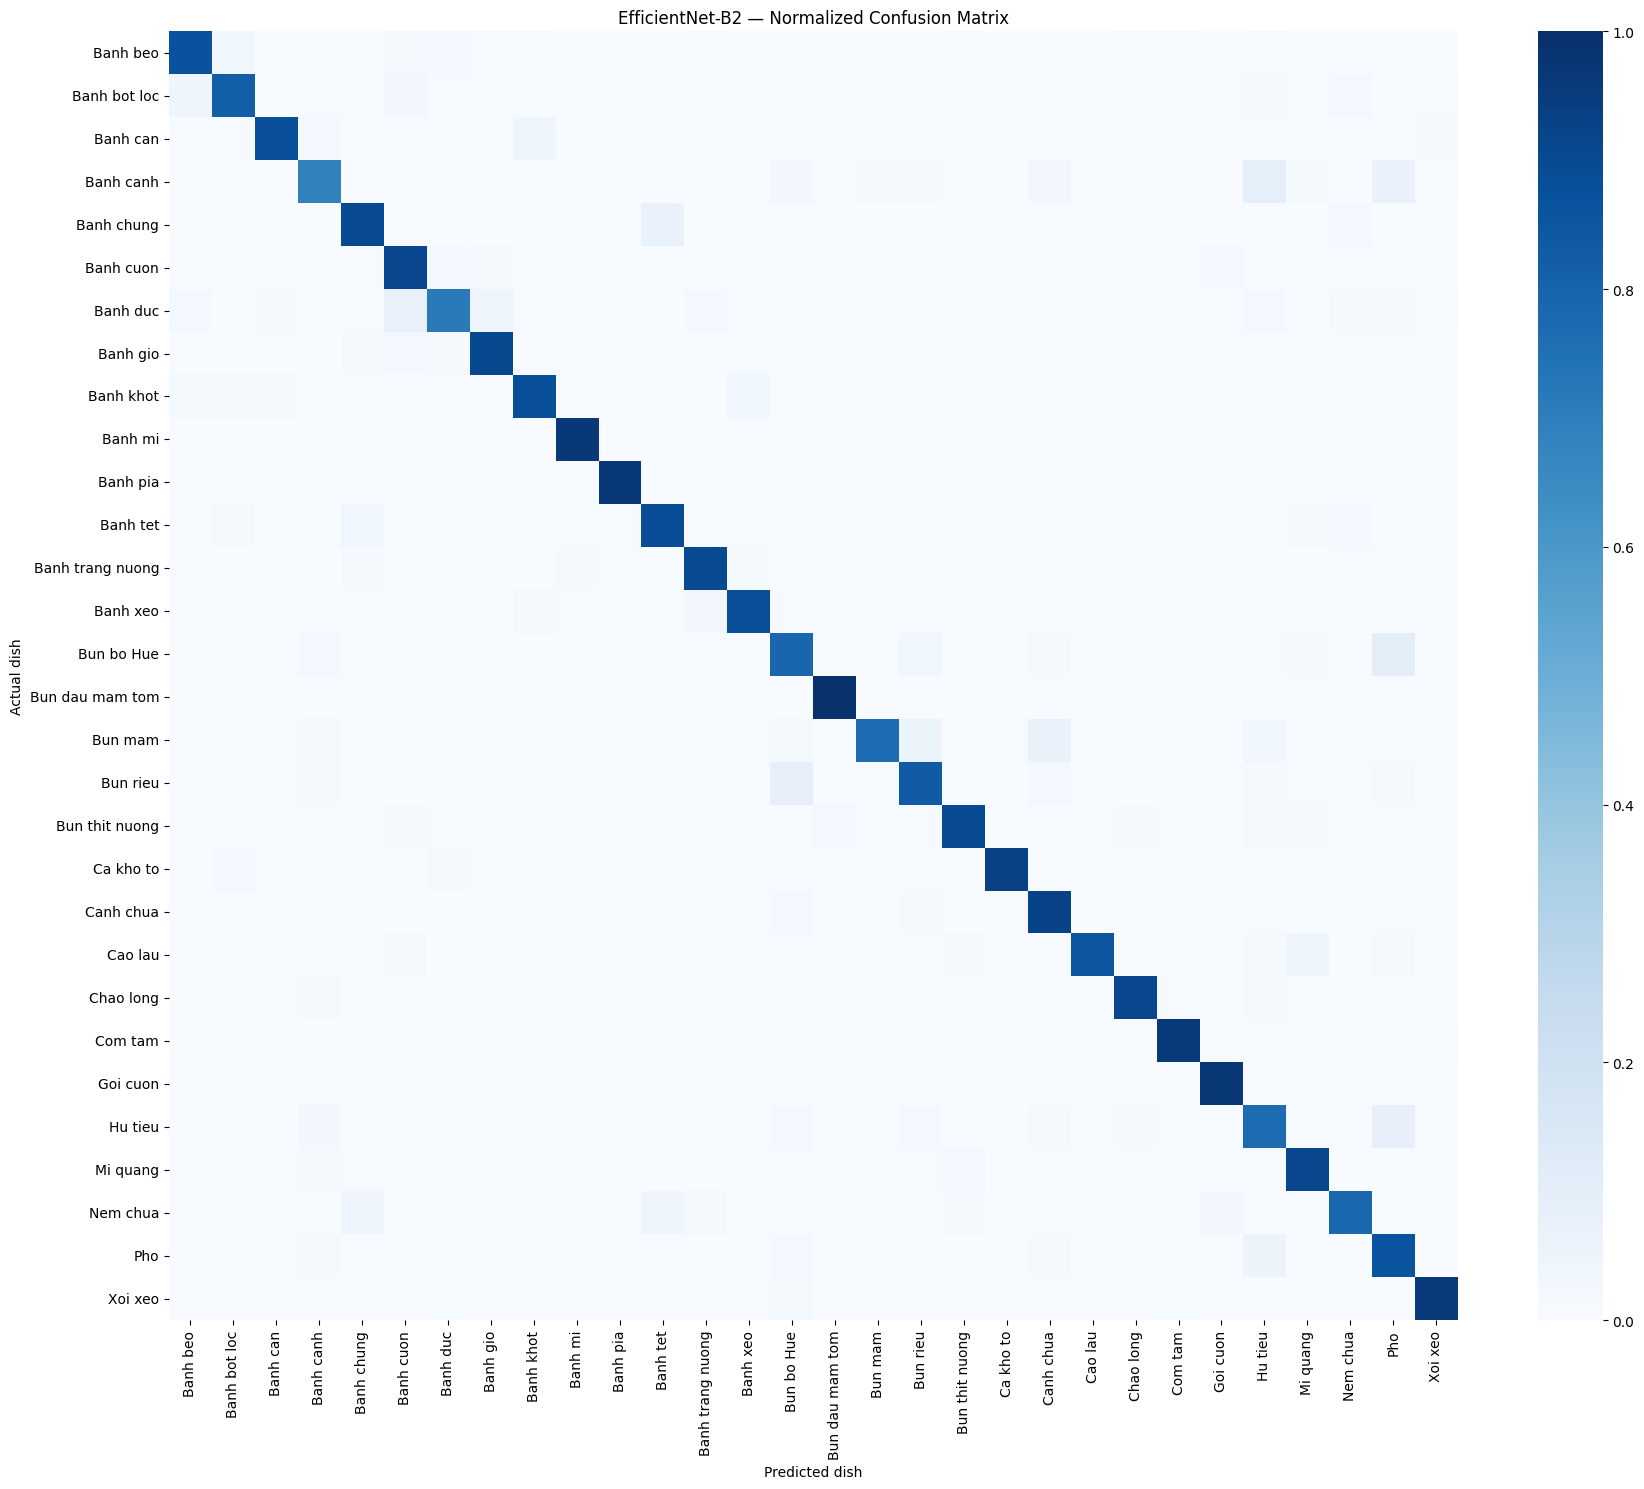

Saved: /content/Cooklen/outputs/confusion_matrix.png


In [26]:
matrix = confusion_matrix(
    all_targets,
    all_predictions,
    normalize="true"
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    matrix,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1
)

plt.title("EfficientNet-B2 — Normalized Confusion Matrix")
plt.xlabel("Predicted dish")
plt.ylabel("Actual dish")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

confusion_path = OUTPUT_DIR / "confusion_matrix.png"

plt.savefig(
    confusion_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", confusion_path)

count_matrix = confusion_matrix(
    all_targets,
    all_predictions
)

mistakes = []

for actual_index in range(len(class_names)):
    for predicted_index in range(len(class_names)):
        if actual_index != predicted_index:
            mistakes.append({
                "actual": class_names[actual_index],
                "predicted": class_names[predicted_index],
                "count": int(
                    count_matrix[actual_index, predicted_index]
                )
            })

mistakes_df = (
    pd.DataFrame(mistakes)
    .sort_values("count", ascending=False)
)

mistakes_df.to_csv(
    OUTPUT_DIR / "confusion_pairs.csv",
    index=False
)

print(mistakes_df.head(15).to_string(index=False))

In [28]:
validation_targets = []
validation_predictions = []
validation_confidences = []

model.eval()

with torch.no_grad():
    for images, labels in tqdm(
        validation_loader,
        desc="Validation confidence"
    ):
        images = images.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=DEVICE.type == "cuda"
        ):
            logits = model(images)

        probabilities = torch.softmax(logits, dim=1)
        confidences, predictions = probabilities.max(dim=1)

        validation_targets.extend(labels.tolist())
        validation_predictions.extend(predictions.cpu().tolist())
        validation_confidences.extend(confidences.cpu().tolist())

validation_targets = np.array(validation_targets)
validation_predictions = np.array(validation_predictions)
validation_confidences = np.array(validation_confidences)

correct = validation_predictions == validation_targets
threshold_rows = []

for threshold in np.arange(0.20, 0.96, 0.05):
    accepted = validation_confidences >= threshold

    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "coverage": accepted.mean(),
        "accepted_accuracy": (
            correct[accepted].mean()
            if accepted.any()
            else np.nan
        ),
        "images_accepted": int(accepted.sum())
    })

threshold_df = pd.DataFrame(threshold_rows)

print(
    threshold_df.to_string(
        index=False,
        formatters={
            "coverage": "{:.2%}".format,
            "accepted_accuracy": "{:.2%}".format
        }
    )
)

eligible = threshold_df[
    (threshold_df["accepted_accuracy"] >= 0.90) &
    (threshold_df["coverage"] >= 0.20)
]

CONFIDENCE_THRESHOLD = (
    float(eligible.iloc[0]["threshold"])
    if not eligible.empty
    else 0.60
)

print(
    "\nSelected confidence threshold:",
    CONFIDENCE_THRESHOLD
)

Validation confidence:   0%|          | 0/79 [00:00<?, ?it/s]

 threshold coverage accepted_accuracy  images_accepted
      0.20   98.88%            89.12%             2473
      0.25   96.96%            89.81%             2425
      0.30   95.16%            90.67%             2380
      0.35   92.32%            91.94%             2309
      0.40   89.52%            93.30%             2239
      0.45   86.93%            94.11%             2174
      0.50   84.09%            95.10%             2103
      0.55   80.89%            95.90%             2023
      0.60   77.65%            96.50%             1942
      0.65   74.61%            97.00%             1866
      0.70   70.21%            97.38%             1756
      0.75   65.61%            98.11%             1641
      0.80   59.14%            98.65%             1479
      0.85   51.26%            99.14%             1282
      0.90   38.46%            99.06%              962
      0.95   17.87%            99.11%              447

Selected confidence threshold: 0.3


Saving Bún_đậu_mắm_tôm_(2019).jpg to Bún_đậu_mắm_tôm_(2019).jpg


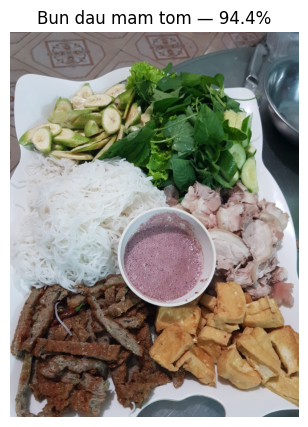

{
  "filename": "Bún_đậu_mắm_tôm_(2019).jpg",
  "predictions": [
    {
      "dish": "Bun dau mam tom",
      "confidence": 0.9438
    },
    {
      "dish": "Com tam",
      "confidence": 0.0081
    },
    {
      "dish": "Bun thit nuong",
      "confidence": 0.0059
    }
  ],
  "needs_confirmation": false
}


In [29]:
import io
import json
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

uploaded = files.upload()

for filename, contents in uploaded.items():
    image = Image.open(io.BytesIO(contents)).convert("RGB")
    input_tensor = evaluation_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()

    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1)[0]
        top_values, top_indices = probabilities.topk(3)

    predictions = []

    for confidence, class_index in zip(
        top_values.cpu(),
        top_indices.cpu()
    ):
        predictions.append({
            "dish": class_names[class_index.item()],
            "confidence": round(confidence.item(), 4)
        })

    result = {
        "filename": filename,
        "predictions": predictions,
        "needs_confirmation": (
            predictions[0]["confidence"] < CONFIDENCE_THRESHOLD
        )
    }

    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{predictions[0]['dish']} — "
        f"{predictions[0]['confidence']:.1%}"
    )
    plt.show()

    print(json.dumps(result, indent=2, ensure_ascii=False))

In [31]:
import time

sample_images, _ = next(iter(test_loader))
sample = sample_images[:1].to(DEVICE)

model.eval()

# GPU warm-up
with torch.no_grad():
    for _ in range(20):
        _ = model(sample)

torch.cuda.synchronize()

latencies_ms = []

with torch.no_grad():
    for _ in range(100):
        torch.cuda.synchronize()
        start = time.perf_counter()

        _ = model(sample)

        torch.cuda.synchronize()
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000)

latency_mean = float(np.mean(latencies_ms))
latency_p50 = float(np.percentile(latencies_ms, 50))
latency_p95 = float(np.percentile(latencies_ms, 95))

print(f"Mean latency: {latency_mean:.2f} ms")
print(f"P50 latency:  {latency_p50:.2f} ms")
print(f"P95 latency:  {latency_p95:.2f} ms")

Mean latency: 25.60 ms
P50 latency:  20.94 ms
P95 latency:  45.45 ms


In [32]:
import json

final_model_path = OUTPUT_DIR / "cooklen_efficientnet_b2.pt"

final_artifact = {
    "model_state_dict": model.state_dict(),
    "architecture": "efficientnet_b2",
    "classes": class_names,
    "class_to_idx": {
        name: index
        for index, name in enumerate(class_names)
    },
    "input_size": [3, IMAGE_SIZE, IMAGE_SIZE],
    "normalization": {
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225]
    },
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "validation_metrics": checkpoint["validation_metrics"],
    "test_metrics": test_metrics,
    "latency": {
        "device": torch.cuda.get_device_name(0),
        "batch_size": 1,
        "mean_ms": latency_mean,
        "p50_ms": latency_p50,
        "p95_ms": latency_p95
    }
}

torch.save(final_artifact, final_model_path)

experiment_summary = {
    "dataset": "30VNFoods",
    "original_images": 25136,
    "clean_images": len(clean_manifest),
    "train_images": len(train_dataset),
    "validation_images": len(validation_dataset),
    "test_images": len(test_dataset),
    "classes": len(class_names),
    "unreadable_images": len(bad_df),
    "exact_duplicate_copies": len(duplicate_df),
    "excluded_files": len(excluded_paths),
    "model": "EfficientNet-B2",
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "validation_metrics": checkpoint["validation_metrics"],
    "test_metrics": test_metrics,
    "latency": final_artifact["latency"]
}

with open(
    OUTPUT_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        experiment_summary,
        file,
        indent=2,
        ensure_ascii=False
    )

with open(
    OUTPUT_DIR / "classes.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(class_names, file, indent=2, ensure_ascii=False)

print("Final model:", final_model_path)
print("Size:", final_model_path.stat().st_size / 1024**2, "MB")

Final model: /content/Cooklen/outputs/cooklen_efficientnet_b2.pt
Size: 29.98032283782959 MB


In [33]:
import shutil
from google.colab import files

final_zip = shutil.make_archive(
    "/content/Cooklen_30VNFoods_final",
    "zip",
    OUTPUT_DIR
)

print("Package:", final_zip)
print("Size:", Path(final_zip).stat().st_size / 1024**2, "MB")

files.download(final_zip)

Package: /content/Cooklen_30VNFoods_final.zip
Size: 55.66294574737549 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>